# T2 - Calibration

Models are simplifications of the real world, and quantities in the model (like the force of infection) represent the aggregation of many different factors. As a result, there can be uncertainty as to what value of the parameters most accurately reflects the real world - for instance, the population force of infection varies with the average number of contacts per person per day, but this quantity may not be well constrained. The first step in running a model is to improve estimates of the parameter values for a particular setting, using data from that setting. Typically, the model is started off at some point in the past (e.g. 2000), such that the initial compartment sizes correspond to the data in the simulation start year. The model is then run up to the current year, with the compartment sizes changing due to the model parameters. The model predictions can then be compared to the actual data for those same years. This allows model parameters to be adjusted to best match the existing data. These same parameters are then used for future projections.

To see calibration in effect, consider the following simple example:

In [1]:
import atomica as at
P = at.Project(framework='assets/T2/t2_framework_1.xlsx',databook='assets/T2/t2_databook_1.xlsx', do_run=False)

/opt/hostedtoolcache/Python/3.7.9/x64/lib/python3.7/site-packages/traitlets-5.0.4-py3.7.egg/traitlets/traitlets.py:2945: FutureWarning: --rc={'figure.dpi': 96} for dict-traits is deprecated in traitlets 5.0. You can pass --rc <key=value> ... multiple times to add items to a dict.
  FutureWarning,


First, we inspect the default calibration by running the model and plotting it along with the data. To plot the data, pass the project's data to the plotting function (in this case, `plot_series`) - this will automatically add scatter points to the plot based on the data in the databook.

Elapsed time for running "default": 0.0104s


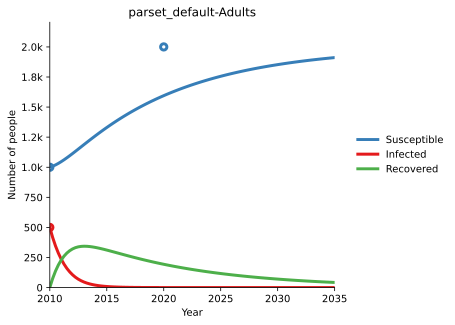

In [2]:
result = P.run_sim()
d = at.PlotData(result,project=P)
at.plot_series(d, data=P.data);

Notice how the number of susceptible people and infected people exactly match the data points in the simulation start year - as noted above, this is because the model is initialized from the data values in that year. There are some conditions under which the model won't exactly match the data in the initial year, such as if the initialization characteristics are overdetermined, but these situations are rare. 

We can see, however, that the model does not predict enough susceptible people in 2020. There could be many reasons for this, and determining what parts of the model should be changed can often be something of an art. It typically reflects your understanding of the assumptions that were made in designing the framework, and also uncertainties and bias present in the input data. For example, the methodology used to gather data used for the calibration might provide hints as to which parameters to change first.

In this case, as there are insufficient people, it might be the case that the birth rate was too low. There are two ways to address this

- You could go back to the databook and enter a larger value for the birth rate
- You can add a 'scale factor' to the parameter set, which scales the parameter value up or down

Either approach can be used and would provide equivalent results. However, changing the value in the databook will also change the scatter points on plots, so it should generally only be used in cases where the value corresponds to a model assumption. In cases where the databook contains actual country data, it is preferable to keep the databook as a faithful representation of the actual data that was gathered. 

<div class="alert alert-block alert-info">
The web interfaces (such as the Cascade Analysis Tool) perform calibration using scale factors. The scale factors shown on the website correspond to the values being set here.
</div>

To set a scale factor, create a `ParameterSet` either by copying an existing one, or creating a new one. Then, access the `pars` attribute to look up the parameter you wish to change, and set the `y_factor` for the population you want to change:

In [3]:
p2 = P.parsets[0].copy()
p2.pars['b_rate'].y_factor['adults'] = 2

The example above doubled the birth rate. Now we can run the model again, and see how the results have changed. Notice how the `PlotData` command is being called with both the original results object, and the new results object, allowing both model runs to be shown on the same plot.

Elapsed time for running "default": 0.0109s


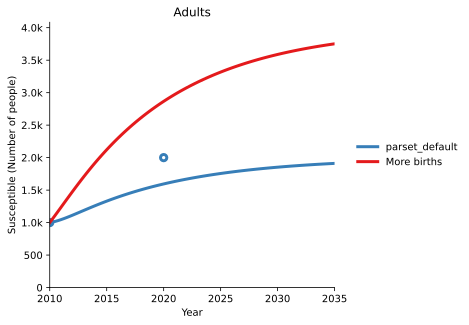

In [4]:
r2 = P.run_sim(parset=p2,result_name = 'More births')
d = at.PlotData([result,r2], outputs='sus',project=P)
at.plot_series(d,axis='results',data=P.data);

We can see that we have considerably overshot the data, indicating that doubling the birth rate was much too big a change. This would typically be the first step in an iterative process, where you adjust the scale factor, inspect the data, and then make further adjustments. 

Automated calibration is also available via the project's `calibrate` method. This will automatically adjust parameter values to match the data. To use this function, you need to specify which parameters to set scale factors for, and which variables in the databook to compute calibration quality from. The framework can provide defaults for which parameters to automatically calibrate, or you can pass a list of those parameters in directly. In this example, we will pass in `b_rate` because we want to adjust the birth rate, and we will use `sus` as a measurable since we want to match the number of susceptible people. The configuration therefore corresponds to the example shown above. 

In [5]:
p3 = P.calibrate(max_time=10, parset='default', adjustables=['b_rate'], measurables=['sus']);

Elapsed time for running "default": 0.00741s


Elapsed time for running "default": 0.00784s


     step 1 (0.0 s) ++ (orig: 0.20252 | best:0.20252 | new:0.13898 | diff:-0.063540)
Elapsed time for running "default": 0.00653s


     step 2 (0.0 s) ++ (orig: 0.20252 | best:0.13898 | new:0.043664 | diff:-0.095321)
Elapsed time for running "default": 0.00660s


     step 3 (0.0 s) -- (orig: 0.20252 | best:0.043664 | new:0.099338 | diff:0.055675)
Elapsed time for running "default": 0.00626s


...

     step 42 (0.4 s) -- (orig: 0.20252 | best:0.000010022 | new:0.000026591 | diff:0.000016569)
Elapsed time for running "default": 0.00704s


     step 43 (0.4 s) -- (orig: 0.20252 | best:0.000010022 | new:0.000018306 | diff:0.0000082847)
Elapsed time for running "default": 0.00690s


     step 44 (0.4 s) ++ (orig: 0.20252 | best:0.000010022 | new:0.0000096161 | diff:-0.00000040552)

Elapsed time for running "default": 0.00959s


     step 45 (0.4 s) -- (orig: 0.20252 | best:0.0000096161 | new:0.000039073 | diff:0.000029457)
===  Absolute improvement too small (0.00000044967 < 0.0000010000) (45 steps, orig: 0.20252 | best: 0 | ratio: 0) ===


The result of automated calibration is another `ParameterSet`. We can inspect the scale factor that the algorithm found:

In [6]:
p3.pars['b_rate'].y_factor

#0: "adults": 1.3186893939971924


and we can run the model to compare the automated calibration to the original default calibration:

Elapsed time for running "default": 0.0113s


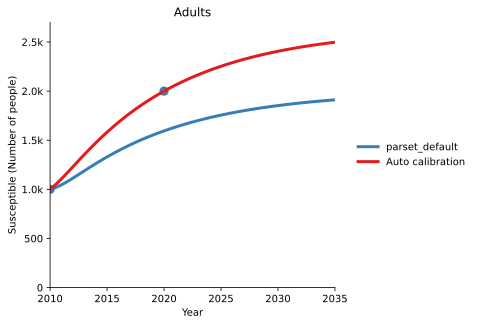

In [7]:
r3 = P.run_sim(parset=p3,result_name = 'Auto calibration')
d = at.PlotData([result,r3], outputs='sus',project=P)
at.plot_series(d,axis='results',data=P.data);

## Calibration tips

While calibrations can vary significantly from model-to-model, some general tips are

- Match coarse-grained quantities first, followed by fine-grained quantities. For example, for TB you might calibrate it in the following order:
    1. Match population size (adjusting birth rate and death rate)
    2. Match disease prevalance (adjusting force of infection)
    3. Match drug-resistant/drug-susceptible split (adjusting proportion of infections that are drug-resistant)
